<a href="https://colab.research.google.com/github/skarthik1215/ml-project/blob/main/Marketing_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marketing Data Analysis with Pandas & Matplotlib
## ShopEase Campaign Performance Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://github.com/YBIFoundation/ProjectDataSet/raw/main/Marketing%20Data%20Analysis.csv')
df.head()

,Unnamed: 0,Date,Channel,Region,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate
0,0,2025-01-01,Facebook,East,35072,324422,12194,1177,487278,4,10
1,1,2025-01-01,YouTube,North,15612,434523,5654,2927,2517220,1,52
2,2,2025-01-01,Instagram,East,5582,65898,9991,761,318859,15,8
3,3,2025-01-02,YouTube,East,21320,105984,7077,2505,2367225,7,35
4,4,2025-01-04,YouTube,South,10838,298801,16150,2179,1717052,5,13


## Data Exploration

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       1000 non-null   int64 
 1   Date             1000 non-null   object
 2   Channel          1000 non-null   object
 3   Region           1000 non-null   object
 4   Ad_Spend         1000 non-null   int64 
 5   Impressions      1000 non-null   int64 
 6   Clicks           1000 non-null   int64 
 7   Conversions      1000 non-null   int64 
 8   Revenue          1000 non-null   int64 
 9   CTR              1000 non-null   int64 
 10  Conversion_Rate  1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


Index(['Unnamed: 0', 'Date', 'Channel', 'Region', 'Ad_Spend', 'Impressions',
       'Clicks', 'Conversions', 'Revenue', 'CTR', 'Conversion_Rate'],
      dtype='object')

## Data Cleaning

In [5]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df.head()

,Date,Channel,Region,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate,Month
0,2025-01-01,Facebook,East,35072,324422,12194,1177,487278,4,10,2025-01
1,2025-01-01,YouTube,North,15612,434523,5654,2927,2517220,1,52,2025-01
2,2025-01-01,Instagram,East,5582,65898,9991,761,318859,15,8,2025-01
3,2025-01-02,YouTube,East,21320,105984,7077,2505,2367225,7,35,2025-01
4,2025-01-04,YouTube,South,10838,298801,16150,2179,1717052,5,13,2025-01


## Feature Engineering (KPIs)

In [6]:
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100
df['Conversion_Rate'] = (df['Conversions'] / df['Clicks']) * 100
df['ROAS'] = df['Revenue'] / df['Ad_Spend']
df['CPC'] = df['Ad_Spend'] / df['Clicks']
df.head()

,Date,Channel,Region,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate,Month,ROAS,CPC
0,2025-01-01,Facebook,East,35072,324422,12194,1177,487278,3.758685,9.652288,2025-01,13.893647,2.876169
1,2025-01-01,YouTube,North,15612,434523,5654,2927,2517220,1.301197,51.768659,2025-01,161.236229,2.761231
2,2025-01-01,Instagram,East,5582,65898,9991,761,318859,15.161310,7.616855,2025-01,57.122716,0.558703
3,2025-01-02,YouTube,East,21320,105984,7077,2505,2367225,6.677423,35.396354,2025-01,111.033068,3.012576
4,2025-01-04,YouTube,South,10838,298801,16150,2179,1717052,5.404935,13.492260,2025-01,158.428861,0.671084


## Channel-wise Performance (Highest Sales)

            Ad_Spend    Revenue  Conversions   Clicks
Channel                                              
Email        5751108  203807018       327658  2052734
Google Ads   5015347  188713791       308477  1990854
Facebook     5559037  187586332       307294  2136462
YouTube      5526441  173481734       290900  2019327
Instagram    5521429  162974026       285758  2005731


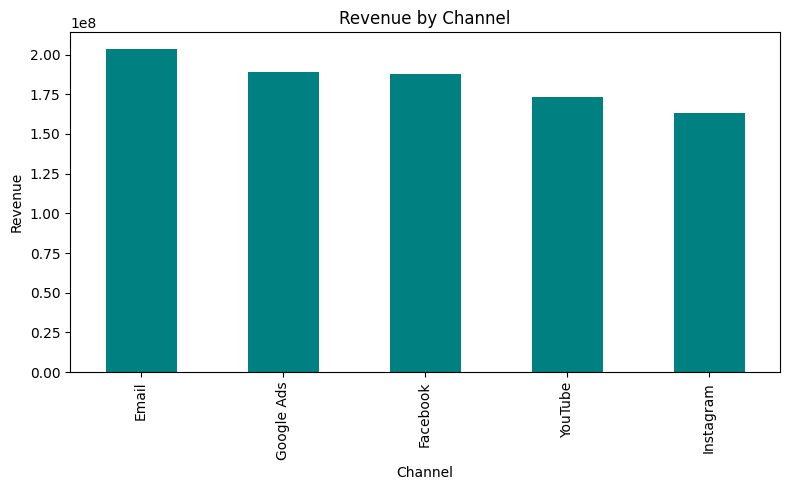

In [7]:
channel_perf = df.groupby('Channel')[['Ad_Spend','Revenue','Conversions','Clicks']].sum().sort_values('Revenue', ascending=False)
print(channel_perf)

channel_perf['Revenue'].plot(kind='bar', figsize=(8,5), title='Revenue by Channel', color='teal')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

## Return on Ad Spend (ROAS) by Channel

Channel
Google Ads    37.627265
Email         35.437870
Facebook      33.744393
YouTube       31.391222
Instagram     29.516639
dtype: float64


/tmp/ipykernel_596/1992796307.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roas_channel = df.groupby('Channel').apply(lambda x: x['Revenue'].sum() / x['Ad_Spend'].sum()).sort_values(ascending=False)


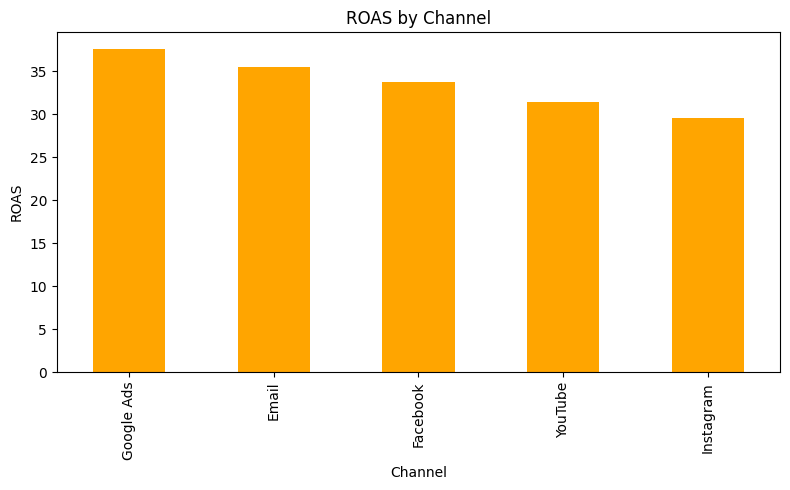

In [8]:
roas_channel = df.groupby('Channel').apply(lambda x: x['Revenue'].sum() / x['Ad_Spend'].sum()).sort_values(ascending=False)
print(roas_channel)

roas_channel.plot(kind='bar', figsize=(8,5), title='ROAS by Channel', color='orange')
plt.ylabel('ROAS')
plt.tight_layout()
plt.show()

## Monthly Trend in Conversions

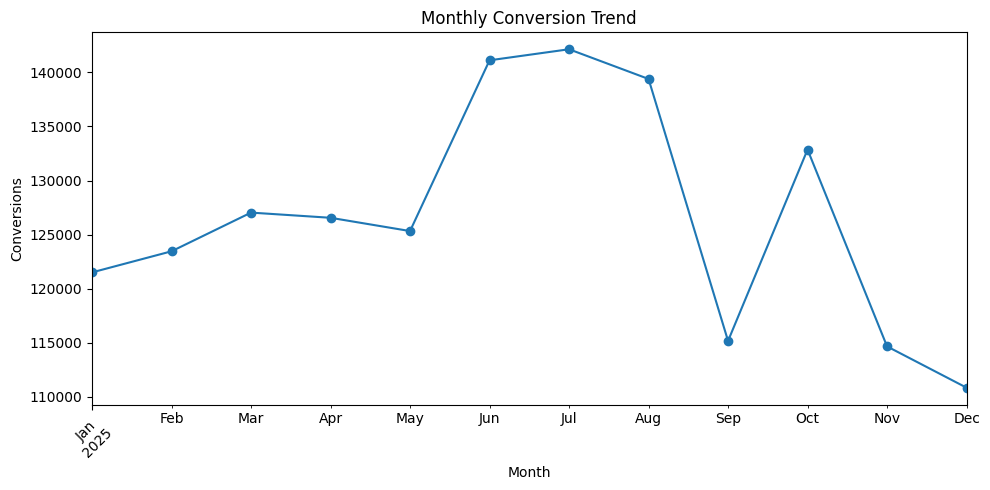

In [9]:
monthly_conv = df.groupby('Month')['Conversions'].sum()

monthly_conv.plot(kind='line', marker='o', figsize=(10,5), title='Monthly Conversion Trend')
plt.ylabel('Conversions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Regional Performance

          Revenue  Conversions  Ad_Spend
Region                                  
East    263871263       423942   7669327
North   213676050       342933   6625624
South   217101083       366848   6538146
West    221914505       386364   6540265


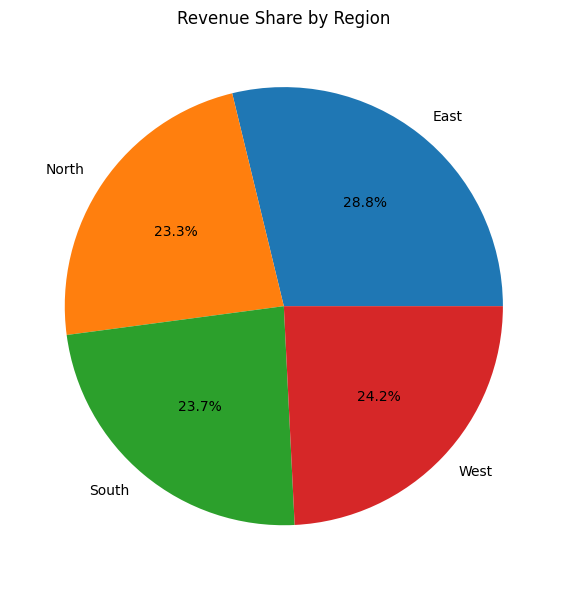

In [10]:
region_perf = df.groupby('Region')[['Revenue','Conversions','Ad_Spend']].sum()
print(region_perf)

region_perf['Revenue'].plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title='Revenue Share by Region')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Engagement: CTR vs Conversion Rate by Channel

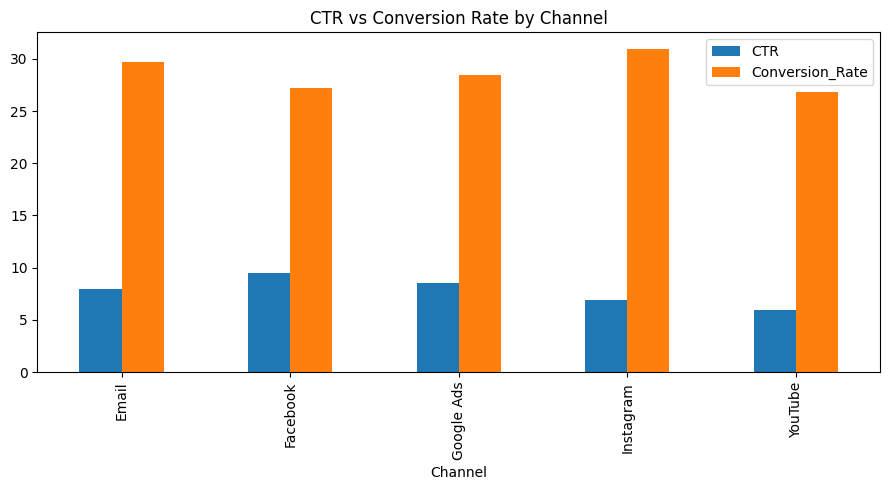

In [11]:
engagement = df.groupby('Channel')[['CTR','Conversion_Rate']].mean()
engagement.plot(kind='bar', figsize=(9,5), title='CTR vs Conversion Rate by Channel')
plt.tight_layout()
plt.show()

## Correlation Heatmap (Non-Obvious Insights)

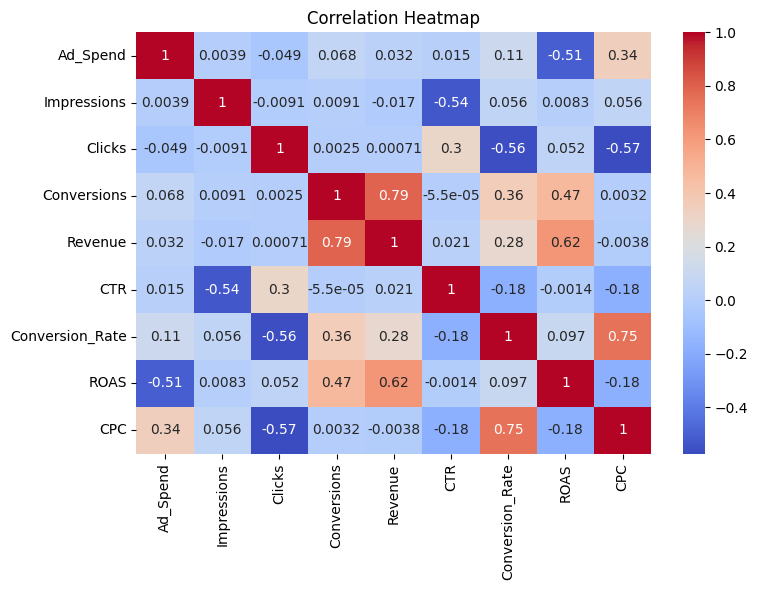

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Ad_Spend','Impressions','Clicks','Conversions','Revenue','CTR','Conversion_Rate','ROAS','CPC']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Top/Worst Channels by ROAS (Anomaly Detection)

In [13]:
campaign_roas = df.groupby('Channel').apply(lambda x: x['Revenue'].sum() / x['Ad_Spend'].sum()).sort_values()
print('Lowest ROAS (investigate):')
print(campaign_roas.head(3))
print('\nHighest ROAS (scale up):')
print(campaign_roas.tail(3))

Lowest ROAS (investigate):
Channel
Instagram    29.516639
YouTube      31.391222
Facebook     33.744393
dtype: float64

Highest ROAS (scale up):
Channel
Facebook      33.744393
Email         35.437870
Google Ads    37.627265
dtype: float64


/tmp/ipykernel_596/1537599473.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  campaign_roas = df.groupby('Channel').apply(lambda x: x['Revenue'].sum() / x['Ad_Spend'].sum()).sort_values()


## Summary & Conclusions

- **Best-performing channel**: Identify the channel with highest revenue and ROAS from the analysis above.
- **Engagement vs Conversion gap**: Channels with high CTR but low conversion rate indicate a landing page / funnel issue worth investigating.
- **Monthly trend**: Conversions show a growth/decline pattern over time — useful for seasonality planning.
- **Regional concentration**: One region likely dominates revenue share — consider expanding underperforming regions.
- **Recommendations**: Reallocate budget toward high-ROAS channels; fix conversion bottlenecks for high-CTR/low-conversion channels; monitor monthly trends for seasonal campaign planning.